In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv("/content/dataset.csv")

In [ ]:
df.head()

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,lp001002,male,no,0,graduate,no,5849,0.0,NaN,360.0,1.0,urban,y
1,lp001003,male,yes,1,graduate,no,4583,1508.0,128.0,360.0,1.0,rural,n
2,lp001005,male,yes,0,graduate,yes,3000,0.0,66.0,360.0,1.0,urban,y
3,lp001006,male,yes,0,not graduate,no,2583,2358.0,120.0,360.0,1.0,urban,y
4,lp001008,male,no,0,graduate,no,6000,0.0,141.0,360.0,1.0,urban,y


In [ ]:
df.shape

(614, 13)

In [ ]:
df.isnull().sum() #Check missing values

,0
loan_id,0
gender,13
married,3
dependents,15
education,0
self_employed,32
applicantincome,0
coapplicantincome,0
loanamount,22
loan_amount_term,14


<Axes: >

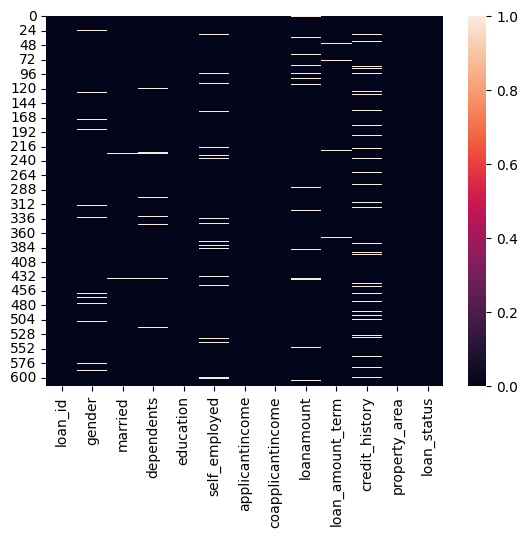

In [ ]:
sb.heatmap((df.isnull()))  #visulize Missing values

In [ ]:
# Handle missing categorical columns using Mode
df["gender"].fillna(df["gender"].mode()[0], inplace=True)
df["dependents"].fillna(df["dependents"].mode()[0], inplace=True)
df["married"].fillna(df["married"].mode()[0], inplace=True)
df["self_employed"].fillna(df["self_employed"].mode()[0], inplace=True)

# Numerical columns using Median
df["loanamount"].fillna(df["loanamount"].median(), inplace=True)
df["loan_amount_term"].fillna(df["loan_amount_term"].median(), inplace=True)

#Credit History using Mode
df["credit_history"].fillna(df["credit_history"].mode()[0], inplace=True)

/tmp/ipykernel_10644/1608678374.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["gender"].fillna(df["gender"].mode()[0], inplace=True)
/tmp/ipykernel_10644/1608678374.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

In [ ]:
df.isnull().sum()

,0
loan_id,0
gender,0
married,0
dependents,0
education,0
self_employed,0
applicantincome,0
coapplicantincome,0
loanamount,0
loan_amount_term,0


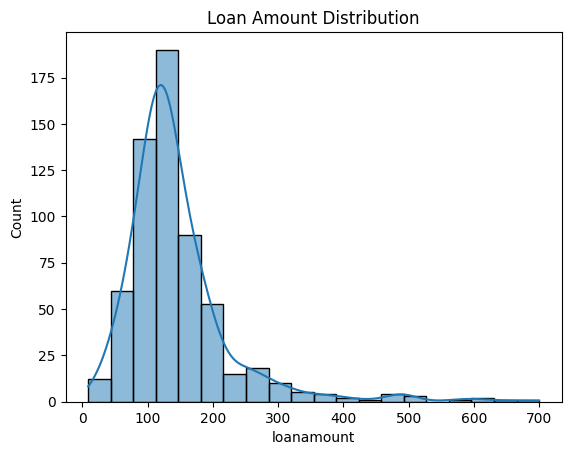

In [ ]:

sb.histplot(
    df["loanamount"],
    bins=20,
    kde=True
)

plt.title("Loan Amount Distribution")
plt.show()

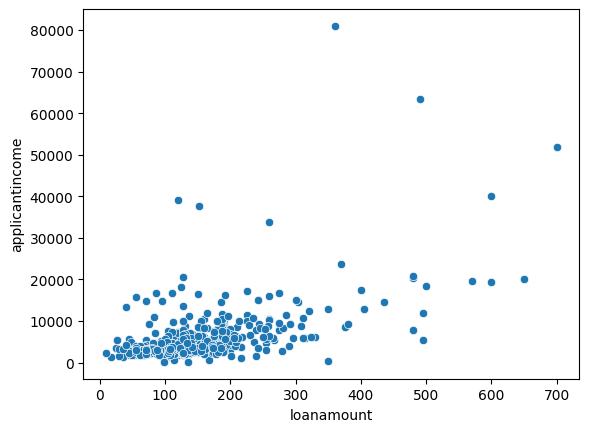

In [ ]:
sb.scatterplot(x="loanamount", y="applicantincome", data=df)
plt.show()

In [ ]:
df.drop("loan_id", axis=1, inplace=True)

In [ ]:
le = LabelEncoder()

categorical_cols = [
    "gender",
    "married",
    "dependents",
    "education",
    "self_employed",
    "property_area",
    "loan_status"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop("loan_status",axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(   # Splits data into training (75%) and testing (25%).
    X, y, test_size=0.25, random_state=42
)

model = DecisionTreeClassifier(criterion="gini", max_depth= 7, random_state=42)
model.fit(X_train, y_train)


R_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, R_pred))
print("Confusuion metrix:", confusion_matrix(y_test, R_pred))


Accuracy: 0.7207792207792207
Confusuion metrix: [[21 33]
 [10 90]]
